<a href="https://colab.research.google.com/github/zeqkik/mdc_lambda_projeto_final/blob/main/04_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input

In [2]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [29]:
def predict_and_evaluate(model, features, labels, threeshold = 0.5):

  pred_proba = model.predict(features)
  pred_positive = pred_proba[:, 1]
  pred = np.where(pred_positive > threeshold, 1, 0)
  bal_acc = balanced_accuracy_score(labels, pred)

  print('=='*10)
  print(f'Balanced Accuracy: {bal_acc}')
  print('=='*10)

  report = classification_report(labels, pred, zero_division=0)
  print(report)
  plot_confusion_matrix(labels, pred, ['benigna', 'maligna'], 2)


  return pred_proba, pred, bal_acc, report

In [33]:
def plot_roc_curve(true: np.ndarray, pred: np.ndarray):
    prob_positive = pred[:, 1]

    fpr, tpr, thresholds = roc_curve(true, prob_positive)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [3]:
IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [4]:
BATCH_SIZE = 1024
BASE_DIR = '/content/drive/MyDrive/MDC_data/images/'


In [5]:
# Carregamento o dataframe de rótulos e criação do conjunto de dados como
# Dataset para obter performance otimizada de processamento

train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")

train_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in train_info['path']]

y_train = train_info['target'].values

train_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_file_paths), tf.constant(y_train)))
train_images_ds = train_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

train_batches = train_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [6]:
val_info = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

val_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in val_info['path']]

y_val = val_info['target'].values

val_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_file_paths), tf.constant(y_val)))
val_images_ds = val_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

val_batches = val_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [7]:
def load_and_preprocess_test(file_path):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image

In [9]:
def plot_confusion_matrix(y_true, y_pred, class_names, NUM_CLASSES=4):
  cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).astype("float")
  cm = cm / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(6,5))
  sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        linewidths=.5,
        linecolor='black'
    )

  plt.title("Matriz de Confusão Normalizada")
  ticks = np.arange(NUM_CLASSES)
  plt.xticks(ticks + 0.5, class_names, rotation=45, ha="right")
  plt.yticks(ticks + 0.5, class_names, rotation=0)
  plt.ylabel("Verdadeiro")
  plt.xlabel("Predito")
  plt.tight_layout()
  plt.show()

In [42]:
classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [43]:
model = tf.keras.applications.ResNet50(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))

for layer in model.layers:
    layer.trainable = False

model = tf.keras.Sequential([model,
                              tf.keras.layers.GlobalAveragePooling2D (),
                              Dense(2, activation = 'softmax')])

input_shape = (None, 224, 224, 3)
model.build(input_shape=input_shape)
model.summary ()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [61]:
import keras

#SGD
sgd = tf.keras.optimizers.SGD(learning_rate = 0.001, momentum = 0.9, decay = 0.001)

#Adam
learning_rate = 1e-5 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile (loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [63]:
n_epochs = 20
model.fit(train_batches,
          epochs = n_epochs,
          class_weight = class_weights,
          validation_data = val_batches)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7481 - loss: 0.6898 - val_accuracy: 0.6868 - val_loss: 0.6907
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6723 - loss: 0.6897 - val_accuracy: 0.5516 - val_loss: 0.6934
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5456 - loss: 0.6896 - val_accuracy: 0.4672 - val_loss: 0.6946
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.4946 - loss: 0.6896 - val_accuracy: 0.4636 - val_loss: 0.6947
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.4958 - loss: 0.6895 - val_accuracy: 0.4884 - val_loss: 0.6944
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5146 - loss: 0.6894 - val_accuracy: 0.4892 - val_loss: 0.6944
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5158 - loss: 0.6893 - val_accuracy: 0.5032 - val_loss: 0.6942
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5355 - loss: 0.6892 - val_accuracy: 0.5044 - val_loss:

3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step
Balanced Accuracy: 0.50262891809909
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      2070
           1       0.25      0.01      0.03       430

    accuracy                           0.82      2500
   macro avg       0.54      0.50      0.46      2500
weighted avg       0.73      0.82      0.75      2500



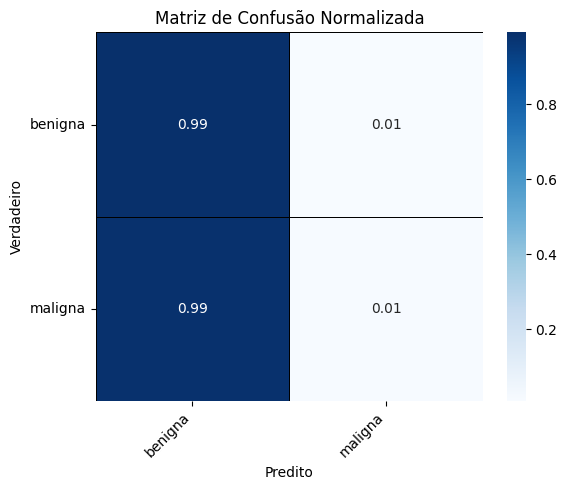

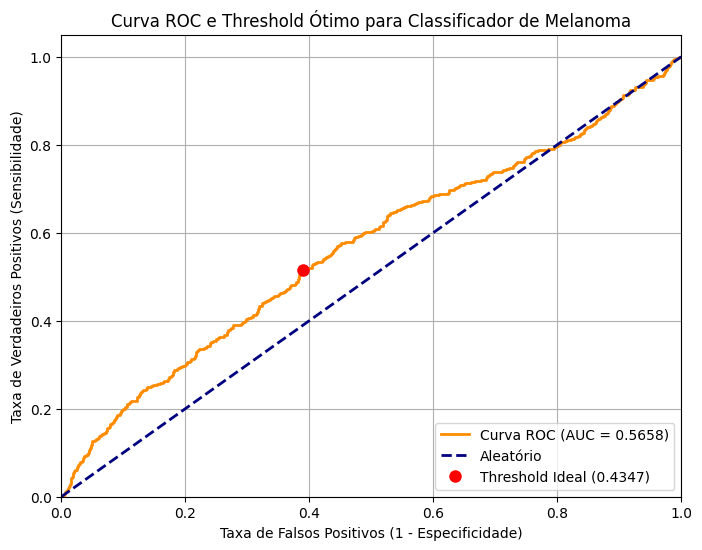

In [73]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val)
optimal_threshold, roc_auc = plot_roc_curve(y_val, val_pred_proba)
